iter=000 wage=1.587601 g_pc=0.151742 pop_mo=0.115101 err=5.88e-01
iter=010 wage=1.505947 g_pc=0.136223 pop_mo=0.712665 err=5.75e-04
iter=020 wage=1.506717 g_pc=0.136093 pop_mo=0.713115 err=1.98e-07
iter=025 wage=1.506716 g_pc=0.136093 pop_mo=0.713116 err=7.39e-08

Revenue-neutral consumption tax rate: 0.0903

Baseline vs no replacement
                     metric  baseline  reform  absolute_change  pct_change
0            wage_scalar_mo    1.5067  1.6340           0.1273      0.0845
1         public_good_pc_mo    0.1361  0.0679          -0.0682     -0.5009
2       population_share_mo    0.7131  0.5913          -0.1218     -0.1708
3        effective_labor_mo    0.7293  0.5703          -0.1589     -0.2180
4                 output_mo    1.6400  1.3909          -0.2491     -0.1519
5        income_tax_revenue    0.0516  0.0000          -0.0516     -1.0000
6   consumption_tax_revenue    0.0454  0.0402          -0.0052     -0.1154
7             total_revenue    0.0971  0.0402          -0.0569

/var/folders/zy/x4gc34qd36q0s944s4dk2n640000gn/T/ipykernel_25060/2338543941.py:313: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("decile", observed=False).apply(
/var/folders/zy/x4gc34qd36q0s944s4dk2n640000gn/T/ipykernel_25060/2338543941.py:313: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("decile", observed=False).apply(


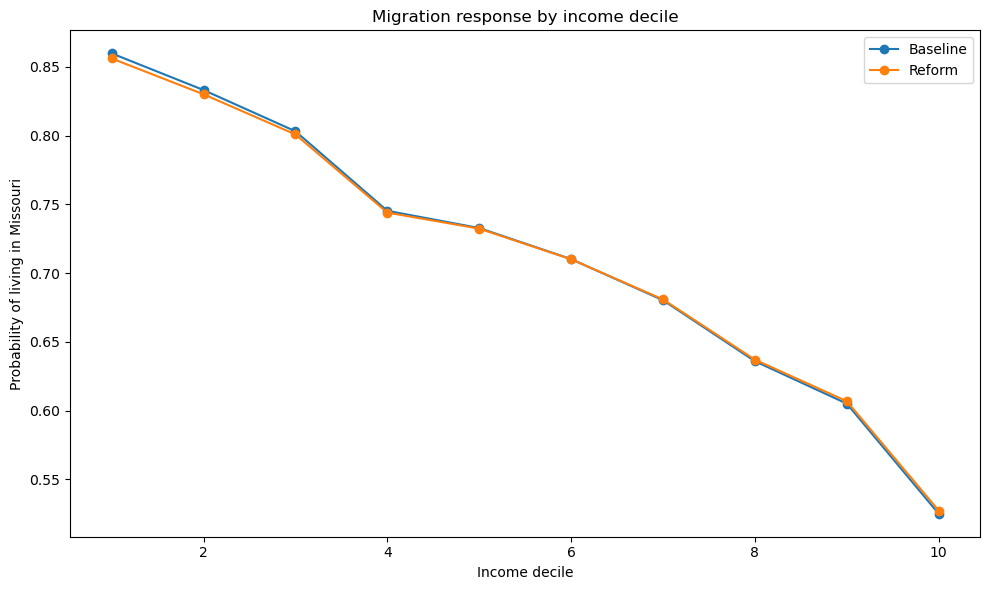

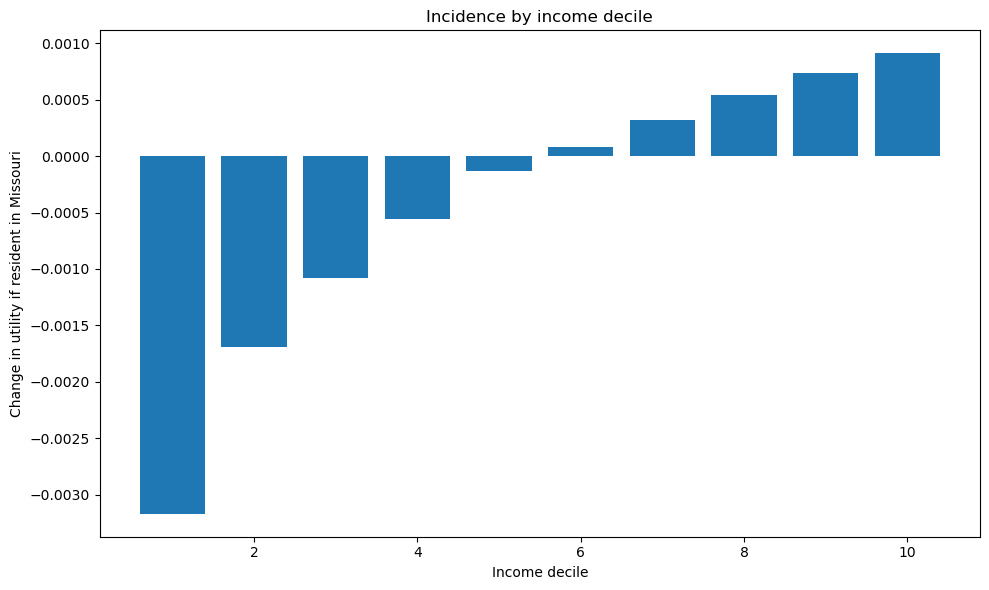

In [1]:

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, root_scalar


@dataclass
class StatePolicy:
    name: str
    income_tax: float
    consumption_tax: float
    amenity: float = 0.0


@dataclass
class AlternativeState:
    name: str = "Alternative"
    base_wage: float = 1.0
    public_good_pc: float = 0.18
    income_tax: float = 0.03
    consumption_tax: float = 0.05
    amenity: float = 0.0


@dataclass
class ModelConfig:
    n_households: int = 4000
    seed: int = 123
    sigma: float = 1.5
    nu: float = 2.0
    gamma_g: float = 0.25
    scale_logit: float = 0.08
    capital: float = 8.0
    productivity: float = 1.0
    alpha: float = 0.33
    gov_efficiency: float = 1.0
    damping: float = 0.35
    tol: float = 1e-8
    max_iter: int = 300
    min_public_good: float = 1e-8


class MissouriTaxModel:
    """
    Static equilibrium model with:
    1. Heterogeneous households
    2. Endogenous labor supply
    3. Migration between Missouri and an outside state
    4. Endogenous Missouri wage from a Cobb-Douglas firm
    5. Government budget financed by income and consumption taxes

    Household utility:
        u(c, l, G) = c^(1-sigma)/(1-sigma) + chi*(1-l)^(1+nu)/(1+nu) + gamma*log(G) + amenity

    With this utility, the labor FOC is:
        c(l)^(-sigma) * ((1-t_y)w)/(1+t_c) = chi * (1-l)^nu

    That lets us solve labor quickly with a scalar root rather than a generic optimizer.
    """

    def __init__(self, config: ModelConfig, alt_state: AlternativeState | None = None):
        self.cfg = config
        self.alt = alt_state or AlternativeState()
        self.rng = np.random.default_rng(config.seed)
        self.households = self._draw_households(config.n_households)

    def _draw_households(self, n: int) -> pd.DataFrame:
        skill = np.exp(self.rng.normal(loc=0.0, scale=0.45, size=n))
        nonlabor_income = np.exp(self.rng.normal(loc=-2.4, scale=0.55, size=n))
        leisure_weight = np.exp(self.rng.normal(loc=-0.15, scale=0.30, size=n))
        move_cost = np.exp(self.rng.normal(loc=-2.0, scale=0.55, size=n))
        df = pd.DataFrame({
            "skill": skill,
            "y0": nonlabor_income,
            "chi": leisure_weight,
            "move_cost": move_cost,
        })
        df["weight"] = 1.0 / n
        df["income_rank"] = df["skill"].rank(pct=True)
        return df

    def utility(self, c: float, leisure: float, g_pc: float, chi: float, amenity: float = 0.0) -> float:
        c = max(c, 1e-12)
        leisure = np.clip(leisure, 1e-9, 1.0 - 1e-9)
        g_pc = max(g_pc, self.cfg.min_public_good)
        sigma = self.cfg.sigma

        if abs(sigma - 1.0) < 1e-10:
            u_c = math.log(c)
        else:
            u_c = (c ** (1.0 - sigma) - 1.0) / (1.0 - sigma)

        nu = self.cfg.nu
        u_l = chi * (leisure ** (1.0 + nu)) / (1.0 + nu)
        u_g = self.cfg.gamma_g * math.log(g_pc)
        return u_c + u_l + u_g + amenity

    def consumption(self, labor: float, wage: float, y0: float, policy: StatePolicy) -> float:
        income_after_tax = (1.0 - policy.income_tax) * wage * labor + y0
        return max(income_after_tax / (1.0 + policy.consumption_tax), 1e-12)

    def labor_foc(self, labor: float, wage: float, y0: float, chi: float, policy: StatePolicy) -> float:
        c = self.consumption(labor, wage, y0, policy)
        lhs = (c ** (-self.cfg.sigma)) * ((1.0 - policy.income_tax) * wage / (1.0 + policy.consumption_tax))
        rhs = chi * ((1.0 - labor) ** self.cfg.nu)
        return lhs - rhs

    def solve_household(self, wage: float, y0: float, chi: float, g_pc: float, policy: StatePolicy) -> Tuple[float, float]:
        eps = 1e-10
        f0 = self.labor_foc(eps, wage, y0, chi, policy)
        f1 = self.labor_foc(1.0 - eps, wage, y0, chi, policy)

        if f0 <= 0 and f1 <= 0:
            labor_star = eps
        elif f0 >= 0 and f1 >= 0:
            labor_star = 1.0 - eps
        else:
            labor_star = brentq(
                lambda l: self.labor_foc(l, wage, y0, chi, policy),
                eps,
                1.0 - eps,
                maxiter=100,
            )

        c_star = self.consumption(labor_star, wage, y0, policy)
        v_star = self.utility(c=c_star, leisure=1.0 - labor_star, g_pc=g_pc, chi=chi, amenity=policy.amenity)
        return float(labor_star), float(v_star)

    def migration_prob(self, v_mo: np.ndarray, v_alt: np.ndarray, move_cost: np.ndarray) -> np.ndarray:
        z = (v_mo - v_alt - move_cost) / self.cfg.scale_logit
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def firm_wage(self, effective_labor: float) -> float:
        effective_labor = max(effective_labor, 1e-10)
        A = self.cfg.productivity
        K = self.cfg.capital
        alpha = self.cfg.alpha
        return (1.0 - alpha) * A * (K ** alpha) * (effective_labor ** (-alpha))

    def output(self, effective_labor: float) -> float:
        effective_labor = max(effective_labor, 1e-10)
        A = self.cfg.productivity
        K = self.cfg.capital
        alpha = self.cfg.alpha
        return A * (K ** alpha) * (effective_labor ** (1.0 - alpha))

    def _solve_state_choices(self, wage_scalar: float, g_pc_guess: float, mo_policy: StatePolicy):
        df = self.households
        alt_policy = StatePolicy(
            name=self.alt.name,
            income_tax=self.alt.income_tax,
            consumption_tax=self.alt.consumption_tax,
            amenity=self.alt.amenity,
        )

        n = len(df)
        w_mo = wage_scalar * df["skill"].to_numpy()
        w_alt = self.alt.base_wage * df["skill"].to_numpy()
        y0 = df["y0"].to_numpy()
        chi = df["chi"].to_numpy()

        l_mo = np.empty(n)
        v_mo = np.empty(n)
        c_mo = np.empty(n)
        l_alt = np.empty(n)
        v_alt = np.empty(n)
        c_alt = np.empty(n)

        for i in range(n):
            l_mo[i], v_mo[i] = self.solve_household(w_mo[i], y0[i], chi[i], g_pc_guess, mo_policy)
            c_mo[i] = self.consumption(l_mo[i], w_mo[i], y0[i], mo_policy)

            l_alt[i], v_alt[i] = self.solve_household(w_alt[i], y0[i], chi[i], self.alt.public_good_pc, alt_policy)
            c_alt[i] = self.consumption(l_alt[i], w_alt[i], y0[i], alt_policy)

        return w_mo, w_alt, l_mo, v_mo, c_mo, l_alt, v_alt, c_alt

    def solve_equilibrium(self, mo_policy: StatePolicy, verbose: bool = False) -> Dict[str, object]:
        df = self.households.copy()
        wage_guess = 1.0
        g_pc_guess = 0.18

        for it in range(self.cfg.max_iter):
            w_mo, w_alt, l_mo, v_mo, c_mo, l_alt, v_alt, c_alt = self._solve_state_choices(
                wage_scalar=wage_guess,
                g_pc_guess=g_pc_guess,
                mo_policy=mo_policy,
            )

            p_mo = self.migration_prob(v_mo=v_mo, v_alt=v_alt, move_cost=df["move_cost"].to_numpy())
            wt = df["weight"].to_numpy()
            skill = df["skill"].to_numpy()

            pop_mo = np.sum(wt * p_mo)
            eff_labor_mo = np.sum(wt * p_mo * skill * l_mo)

            wage_implied = self.firm_wage(eff_labor_mo)

            labor_income_mo = wage_guess * skill * l_mo
            inc_tax_rev = np.sum(wt * p_mo * mo_policy.income_tax * labor_income_mo)
            cons_tax_rev = np.sum(wt * p_mo * mo_policy.consumption_tax * c_mo)
            revenue = inc_tax_rev + cons_tax_rev
            g_pc_implied = self.cfg.gov_efficiency * revenue / max(pop_mo, 1e-12)

            wage_new = self.cfg.damping * wage_implied + (1.0 - self.cfg.damping) * wage_guess
            g_pc_new = self.cfg.damping * g_pc_implied + (1.0 - self.cfg.damping) * g_pc_guess

            err = max(abs(wage_new - wage_guess), abs(g_pc_new - g_pc_guess))
            wage_guess = wage_new
            g_pc_guess = max(g_pc_new, self.cfg.min_public_good)

            if verbose and (it % 10 == 0 or err < self.cfg.tol):
                print(f"iter={it:03d} wage={wage_guess:.6f} g_pc={g_pc_guess:.6f} pop_mo={pop_mo:.6f} err={err:.2e}")

            if err < self.cfg.tol:
                break
        else:
            raise RuntimeError("Equilibrium iteration did not converge")

        output_mo = self.output(eff_labor_mo)
        avg_utility_mo = np.sum(wt * p_mo * v_mo) / max(pop_mo, 1e-12)
        avg_utility_all = np.sum(wt * (p_mo * v_mo + (1.0 - p_mo) * v_alt))

        result_df = df.copy()
        result_df["wage_mo"] = wage_guess * result_df["skill"]
        result_df["wage_alt"] = self.alt.base_wage * result_df["skill"]
        result_df["labor_mo"] = l_mo
        result_df["labor_alt"] = l_alt
        result_df["cons_mo"] = c_mo
        result_df["cons_alt"] = c_alt
        result_df["utility_mo"] = v_mo
        result_df["utility_alt"] = v_alt
        result_df["p_mo"] = p_mo
        result_df["labor_income_mo"] = wage_guess * result_df["skill"] * l_mo
        result_df["income_tax_paid_mo"] = mo_policy.income_tax * result_df["labor_income_mo"] * p_mo
        result_df["cons_tax_paid_mo"] = mo_policy.consumption_tax * result_df["cons_mo"] * p_mo

        return {
            "policy": mo_policy,
            "wage_scalar_mo": wage_guess,
            "public_good_pc_mo": g_pc_guess,
            "population_share_mo": pop_mo,
            "effective_labor_mo": eff_labor_mo,
            "output_mo": output_mo,
            "income_tax_revenue": inc_tax_rev,
            "consumption_tax_revenue": cons_tax_rev,
            "total_revenue": revenue,
            "avg_utility_residents_mo": avg_utility_mo,
            "avg_expected_utility_all": avg_utility_all,
            "microdata": result_df,
        }

    def find_revenue_neutral_consumption_tax(
        self,
        baseline_revenue: float,
        income_tax_new: float = 0.0,
        lower: float = 0.0,
        upper: float = 0.35,
    ) -> float:
        def objective(tc: float) -> float:
            pol = StatePolicy(name="candidate", income_tax=income_tax_new, consumption_tax=tc)
            res = self.solve_equilibrium(pol, verbose=False)
            return res["total_revenue"] - baseline_revenue

        f_lo = objective(lower)
        f_hi = objective(upper)
        if f_lo == 0:
            return lower
        if f_hi == 0:
            return upper
        if f_lo * f_hi > 0:
            raise RuntimeError(
                f"Could not bracket a revenue-neutral consumption tax. f({lower})={f_lo:.6f}, f({upper})={f_hi:.6f}"
            )

        sol = root_scalar(objective, bracket=[lower, upper], method="bisect", xtol=1e-4)
        return float(sol.root)

    @staticmethod
    def compare_results(a: Dict[str, object], b: Dict[str, object]) -> pd.DataFrame:
        rows = [
            "wage_scalar_mo",
            "public_good_pc_mo",
            "population_share_mo",
            "effective_labor_mo",
            "output_mo",
            "income_tax_revenue",
            "consumption_tax_revenue",
            "total_revenue",
            "avg_utility_residents_mo",
            "avg_expected_utility_all",
        ]
        out = pd.DataFrame({
            "metric": rows,
            "baseline": [a[r] for r in rows],
            "reform": [b[r] for r in rows],
        })
        out["absolute_change"] = out["reform"] - out["baseline"]
        out["pct_change"] = np.where(np.abs(out["baseline"]) > 1e-12, out["absolute_change"] / out["baseline"], np.nan)
        return out

    @staticmethod
    def decile_table(result: Dict[str, object]) -> pd.DataFrame:
        df = result["microdata"].copy()
        df["decile"] = pd.qcut(df["income_rank"], 10, labels=False) + 1
        out = df.groupby("decile", observed=False).apply(
            lambda g: pd.Series({
                "avg_skill": np.average(g["skill"], weights=g["weight"]),
                "avg_prob_live_mo": np.average(g["p_mo"], weights=g["weight"]),
                "avg_labor_if_mo": np.average(g["labor_mo"], weights=g["weight"]),
                "avg_cons_if_mo": np.average(g["cons_mo"], weights=g["weight"]),
                "avg_income_tax_if_mo": np.average(g["income_tax_paid_mo"], weights=g["weight"]),
                "avg_cons_tax_if_mo": np.average(g["cons_tax_paid_mo"], weights=g["weight"]),
                "avg_utility_if_mo": np.average(g["utility_mo"], weights=g["weight"]),
            })
        ).reset_index()
        return out

    @staticmethod
    def plot_decile_comparison(base_deciles: pd.DataFrame, reform_deciles: pd.DataFrame) -> None:
        merged = base_deciles.merge(reform_deciles, on="decile", suffixes=("_base", "_reform"))

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(merged["decile"], merged["avg_prob_live_mo_base"], marker="o", label="Baseline")
        ax.plot(merged["decile"], merged["avg_prob_live_mo_reform"], marker="o", label="Reform")
        ax.set_xlabel("Income decile")
        ax.set_ylabel("Probability of living in Missouri")
        ax.set_title("Migration response by income decile")
        ax.legend()
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(10, 6))
        utility_change = merged["avg_utility_if_mo_reform"] - merged["avg_utility_if_mo_base"]
        ax.bar(merged["decile"], utility_change)
        ax.set_xlabel("Income decile")
        ax.set_ylabel("Change in utility if resident in Missouri")
        ax.set_title("Incidence by income decile")
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    cfg = ModelConfig(
        n_households=3000,
        seed=42,
        sigma=1.5,
        nu=2.0,
        gamma_g=0.22,
        scale_logit=0.08,
        capital=8.5,
        productivity=1.0,
        alpha=0.33,
        damping=0.35,
        tol=1e-7,
        max_iter=250,
    )

    alt = AlternativeState(
        name="OtherState",
        base_wage=1.02,
        public_good_pc=0.18,
        income_tax=0.03,
        consumption_tax=0.05,
        amenity=0.01,
    )

    model = MissouriTaxModel(cfg, alt_state=alt)

    baseline_policy = StatePolicy(name="Missouri baseline", income_tax=0.047, consumption_tax=0.04225)
    baseline = model.solve_equilibrium(baseline_policy, verbose=True)

    no_replace_policy = StatePolicy(name="Income tax eliminated, no replacement", income_tax=0.0, consumption_tax=0.04225)
    no_replace = model.solve_equilibrium(no_replace_policy, verbose=False)

    revenue_neutral_tc = model.find_revenue_neutral_consumption_tax(
        baseline_revenue=baseline["total_revenue"],
        income_tax_new=0.0,
        lower=0.0,
        upper=0.25,
    )

    rn_policy = StatePolicy(
        name="Income tax eliminated, revenue-neutral consumption tax",
        income_tax=0.0,
        consumption_tax=revenue_neutral_tc,
    )
    revenue_neutral = model.solve_equilibrium(rn_policy, verbose=False)

    print("\nRevenue-neutral consumption tax rate:", round(revenue_neutral_tc, 4))

    print("\nBaseline vs no replacement")
    print(model.compare_results(baseline, no_replace).round(4))

    print("\nBaseline vs revenue-neutral replacement")
    print(model.compare_results(baseline, revenue_neutral).round(4))

    base_deciles = model.decile_table(baseline)
    rn_deciles = model.decile_table(revenue_neutral)

    print("\nBaseline deciles")
    print(base_deciles.round(4))

    print("\nRevenue-neutral reform deciles")
    print(rn_deciles.round(4))

    model.plot_decile_comparison(base_deciles, rn_deciles)
